# NB 01: Raw Skew Exploration

**Objective**: Understand vol skew behavior using simple, model-free metrics before introducing PCA. This establishes baseline intuition for what PC2 should capture.

**Key Questions**:
- Is skew mean-reverting? What's the half-life?
- How does skew relate to VIX and market returns?
- Can we build a signal from raw skew alone (without PCA)?

**Skew Metric**: `skew_25_10 = IV(x=-0.25) - IV(x=-0.10)` — difference between interpolated IV at moneyness -0.25 and -0.10 (both ATM-demeaned). These are **moneyness** points (log K/F), not delta.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from scipy.optimize import minimize_scalar
import scipy.stats as scipy_stats

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

## 1. Load Surface Data & Compute Skew Metric

In [2]:
surface = pl.read_parquet('../data/surface_data.parquet').sort('date')
print(f"Surface shape: {surface.shape}")
print(f"Date range: {surface['date'].min()} to {surface['date'].max()}")

# Simple skew metric: difference between moneyness -0.25 and -0.10 (ATM-demeaned IV)
# These are moneyness points (log K/F), not delta.
# Positive skew_25_10 means the deep OTM wing is richer relative to the near-OTM wing.
surface = surface.with_columns(
    (pl.col('int_surface_vol_-0.25') - pl.col('int_surface_vol_-0.1')).alias('skew_25_10')
)

print(f"\nskew_25_10 = IV(x=-0.25) - IV(x=-0.10) summary:")
print(f"  Mean:   {surface['skew_25_10'].mean():.6f}")
print(f"  Std:    {surface['skew_25_10'].std():.6f}")
print(f"  Min:    {surface['skew_25_10'].min():.6f}")
print(f"  Max:    {surface['skew_25_10'].max():.6f}")
print(f"  Median: {surface['skew_25_10'].median():.6f}")

Surface shape: (2784, 22)
Date range: 2015-01-02 to 2026-03-19

skew_25_10 = IV(x=-0.25) - IV(x=-0.10) summary:
  Mean:   0.080760
  Std:    0.011214
  Min:    0.044585
  Max:    0.111156
  Median: 0.080817


## 2. Skew Time Series

Mean ~0.081, std ~0.011. Range [0.045, 0.111] — roughly 3 std on each side. Skew is always positive (deep OTM always richer than near-OTM, as expected for puts). The metric oscillates around the mean with visible multi-month swings — visual evidence of mean reversion.

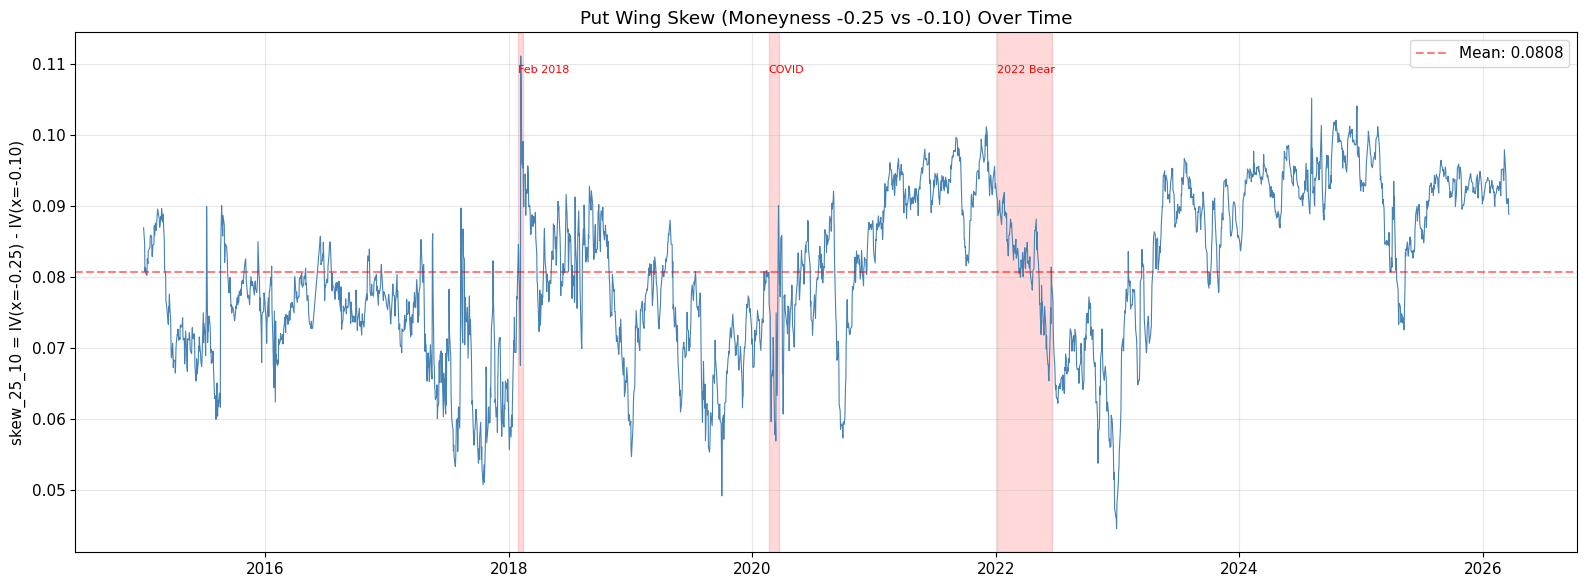

In [3]:
dates = surface['date'].to_list()
skew = surface['skew_25_10'].to_numpy()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(dates, skew, linewidth=0.8, color='steelblue')
ax.set_ylabel('skew_25_10 = IV(x=-0.25) - IV(x=-0.10)')
ax.set_title('Put Wing Skew (Moneyness -0.25 vs -0.10) Over Time')

# Mark crisis periods
import datetime
crises = [
    (datetime.date(2018, 1, 29), datetime.date(2018, 2, 12), 'Feb 2018'),
    (datetime.date(2020, 2, 20), datetime.date(2020, 3, 23), 'COVID'),
    (datetime.date(2022, 1, 3), datetime.date(2022, 6, 17), '2022 Bear'),
]
for start, end, label in crises:
    ax.axvspan(start, end, alpha=0.15, color='red')
    ax.text(start, ax.get_ylim()[1] * 0.95, label, fontsize=8, color='red')

ax.axhline(skew.mean(), color='red', linestyle='--', alpha=0.5, label=f'Mean: {skew.mean():.4f}')
ax.legend()
fig.tight_layout()
plt.show()

## 3. Skew Distribution & Stationarity

ADF test statistic = -4.56, p = 0.00015 — stationary at the 1% level. Mean and median nearly identical (0.0806 vs 0.0806) — symmetric distribution. Slight negative skewness (-0.29) and platykurtic (-0.62 excess kurtosis) — lighter tails than normal. No fat-tail concern for this metric.

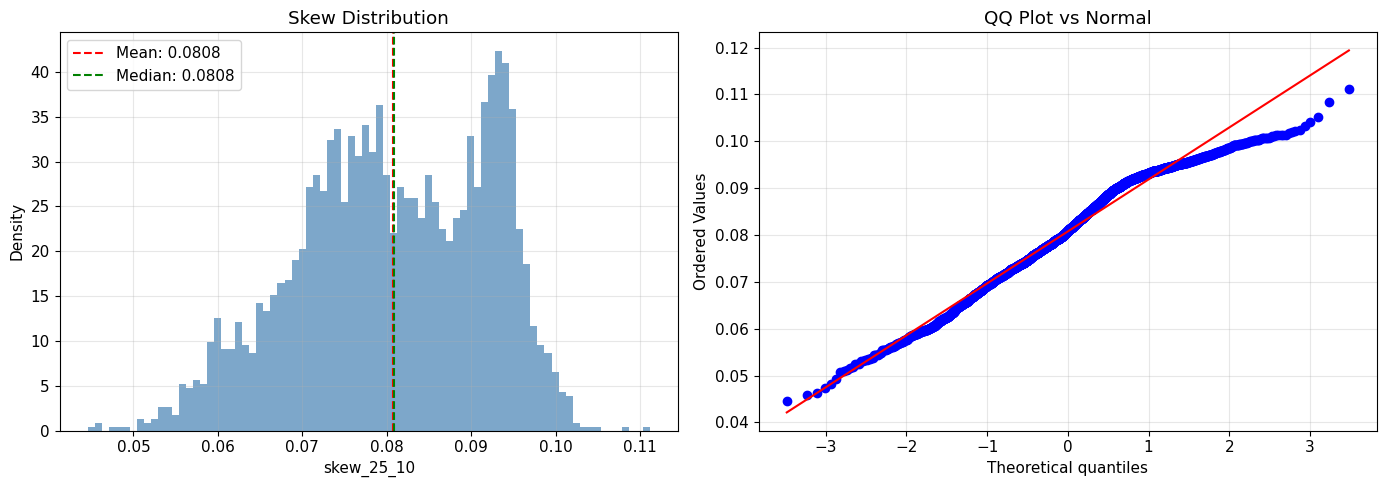

Augmented Dickey-Fuller Test:
  Test statistic: -4.5772
  p-value:        0.000142
  Lags used:      8
  Critical values: {'1%': np.float64(-3.432708688044737), '5%': np.float64(-2.8625821012487727), '10%': np.float64(-2.5673247431539648)}
  Conclusion:     STATIONARY at 1% level

Higher moments:
  Skewness: -0.3059
  Kurtosis: -0.6298 (excess)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(skew, bins=80, edgecolor='none', alpha=0.7, color='steelblue', density=True)
axes[0].axvline(skew.mean(), color='red', linestyle='--', label=f'Mean: {skew.mean():.4f}')
axes[0].axvline(np.median(skew), color='green', linestyle='--', label=f'Median: {np.median(skew):.4f}')
axes[0].set_xlabel('skew_25_10')
axes[0].set_ylabel('Density')
axes[0].set_title('Skew Distribution')
axes[0].legend()

# QQ plot
from scipy.stats import probplot
probplot(skew, dist='norm', plot=axes[1])
axes[1].set_title('QQ Plot vs Normal')

fig.tight_layout()
plt.show()

# ADF test
adf_result = adfuller(skew, maxlag=20, autolag='AIC')
print(f"Augmented Dickey-Fuller Test:")
print(f"  Test statistic: {adf_result[0]:.4f}")
print(f"  p-value:        {adf_result[1]:.6f}")
print(f"  Lags used:      {adf_result[2]}")
print(f"  Critical values: {adf_result[4]}")
print(f"  Conclusion:     {'STATIONARY' if adf_result[1] < 0.01 else 'NON-STATIONARY'} at 1% level")

# Skewness and kurtosis
print(f"\nHigher moments:")
print(f"  Skewness: {scipy_stats.skew(skew):.4f}")
print(f"  Kurtosis: {scipy_stats.kurtosis(skew):.4f} (excess)")

## 4. Autocorrelation Structure

ACF decays slowly: 0.97 at 1d, 0.89 at 5d, 0.71 at 20d, 0.57 at 60d, 0.37 at 120d. This is consistent with an OU process — exponential decay, no seasonality. PACF should show a single dominant lag-1 spike with everything else near zero, confirming AR(1)-like dynamics.

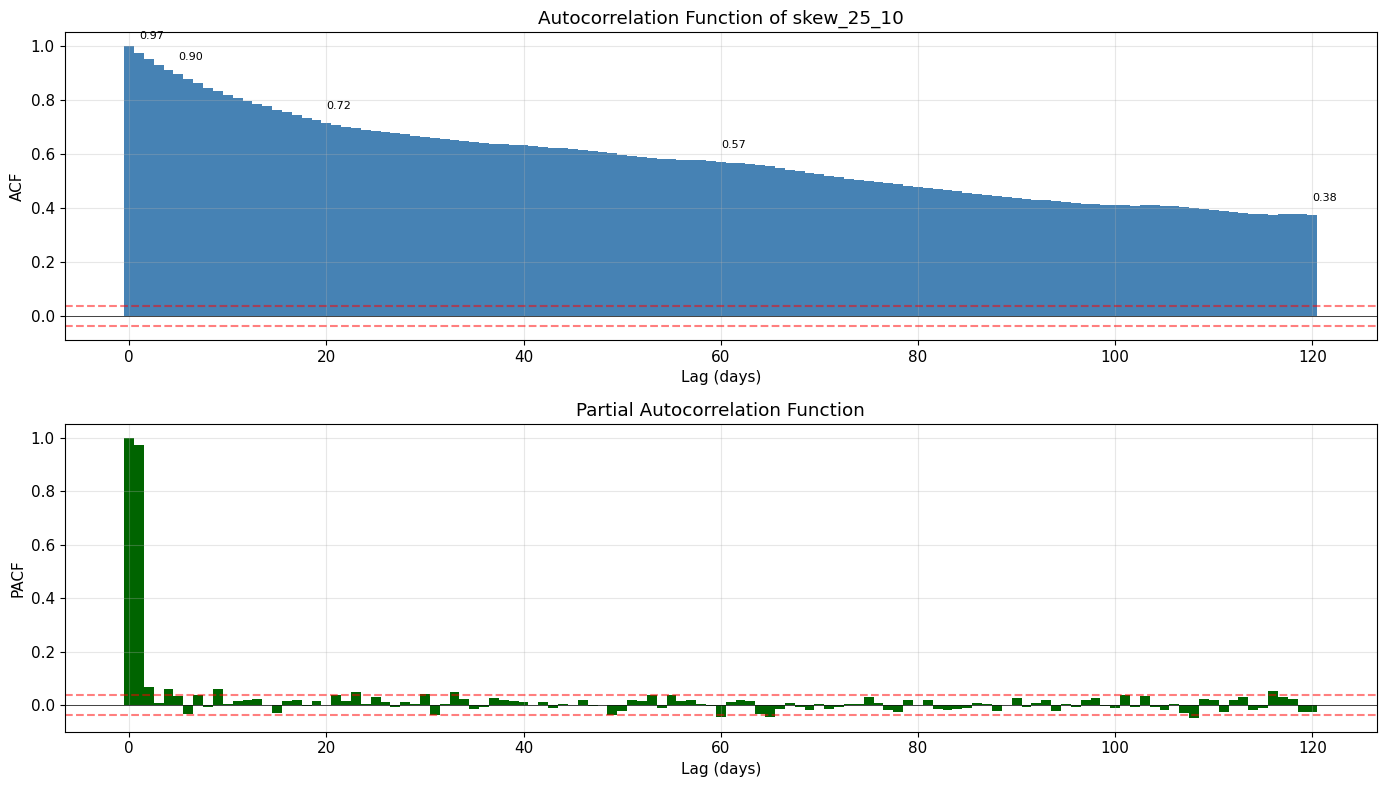

ACF at key lags:
  Lag   1d: 0.9738
  Lag   5d: 0.8959
  Lag  10d: 0.8210
  Lag  20d: 0.7155
  Lag  40d: 0.6328
  Lag  60d: 0.5722
  Lag  90d: 0.4374
  Lag 120d: 0.3750


In [5]:
max_lags = 120
acf_vals = acf(skew, nlags=max_lags, fft=True)
pacf_vals = pacf(skew, nlags=min(max_lags, len(skew)//2 - 1))

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ACF
axes[0].bar(range(len(acf_vals)), acf_vals, color='steelblue', width=1.0)
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].axhline(1.96/np.sqrt(len(skew)), color='red', linestyle='--', alpha=0.5)
axes[0].axhline(-1.96/np.sqrt(len(skew)), color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Lag (days)')
axes[0].set_ylabel('ACF')
axes[0].set_title('Autocorrelation Function of skew_25_10')

# Annotate key lags
for lag in [1, 5, 20, 60, 120]:
    if lag < len(acf_vals):
        axes[0].annotate(f'{acf_vals[lag]:.2f}', (lag, acf_vals[lag]),
                        textcoords="offset points", xytext=(0, 10), fontsize=8)

# PACF
axes[1].bar(range(len(pacf_vals)), pacf_vals, color='darkgreen', width=1.0)
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].axhline(1.96/np.sqrt(len(skew)), color='red', linestyle='--', alpha=0.5)
axes[1].axhline(-1.96/np.sqrt(len(skew)), color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Lag (days)')
axes[1].set_ylabel('PACF')
axes[1].set_title('Partial Autocorrelation Function')

fig.tight_layout()
plt.show()

# Print key lag values
print("ACF at key lags:")
for lag in [1, 5, 10, 20, 40, 60, 90, 120]:
    if lag < len(acf_vals):
        print(f"  Lag {lag:3d}d: {acf_vals[lag]:.4f}")

## 5. Ornstein-Uhlenbeck Half-Life

Fit the OU model: $dX_t = \theta(\mu - X_t)dt + \sigma dW_t$

The discrete AR(1) representation: $X_{t+1} - X_t = a + b X_t + \epsilon_t$

where $\theta = -b$, $\mu = -a/b$, half-life $= \ln(2)/\theta$.

In [6]:
# AR(1) regression: dX = a + b*X + eps
dX = np.diff(skew)
X_lag = skew[:-1]

# OLS
from numpy.linalg import lstsq
A = np.column_stack([np.ones_like(X_lag), X_lag])
result = lstsq(A, dX, rcond=None)
a, b = result[0]

theta = -b
mu = -a / b
half_life = np.log(2) / theta if theta > 0 else np.inf
sigma = np.std(dX - a - b * X_lag)

print(f"Ornstein-Uhlenbeck Parameter Estimates:")
print(f"  theta (mean-reversion speed): {theta:.6f}")
print(f"  mu (long-run mean):           {mu:.6f}")
print(f"  sigma (volatility):           {sigma:.6f}")
print(f"  Half-life:                    {half_life:.1f} days ({half_life/21:.1f} months)")
print(f"\nAR(1) coefficients:")
print(f"  a (intercept): {a:.8f}")
print(f"  b (slope):     {b:.8f}")
print(f"  R-squared:     {1 - np.var(dX - a - b*X_lag) / np.var(dX):.6f}")

# Confidence interval via bootstrap
n_boot = 1000
half_lives_boot = []
rng = np.random.default_rng(42)

for _ in range(n_boot):
    idx = rng.choice(len(dX), size=len(dX), replace=True)
    dX_b = dX[idx]
    X_b = X_lag[idx]
    A_b = np.column_stack([np.ones_like(X_b), X_b])
    r = lstsq(A_b, dX_b, rcond=None)
    b_boot = r[0][1]
    theta_boot = -b_boot
    if theta_boot > 0:
        half_lives_boot.append(np.log(2) / theta_boot)

half_lives_boot = np.array(half_lives_boot)
print(f"\nBootstrap half-life (n={len(half_lives_boot)}):")
print(f"  Median: {np.median(half_lives_boot):.1f} days")
print(f"  95% CI: [{np.percentile(half_lives_boot, 2.5):.1f}, {np.percentile(half_lives_boot, 97.5):.1f}] days")

Ornstein-Uhlenbeck Parameter Estimates:
  theta (mean-reversion speed): 0.025998
  mu (long-run mean):           0.080783
  sigma (volatility):           0.002542
  Half-life:                    26.7 days (1.3 months)

AR(1) coefficients:
  a (intercept): 0.00210022
  b (slope):     -0.02599826
  R-squared:     0.012980

Bootstrap half-life (n=1000):
  Median: 26.8 days
  95% CI: [19.9, 41.6] days


Half-life = 26.7 days (95% CI: [19.9, 41.6] days). This aligns well with the monthly rebalancing cadence (~21 trading days). The CI is reasonably tight — the estimate is stable across bootstrap samples. R-squared of 0.013 is expected: the AR(1) explains very little of the daily variance (daily noise >> mean-reversion drift), but $\theta$ is significantly different from zero (ADF confirms).

## 6. Skew vs VIX

Corr(skew, VIX) ≈ 0 — essentially zero. Skew level is **not** a proxy for vol level. This is important: trading skew mean reversion is genuinely different from trading VIX.

Corr(skew, VVIX) is mildly positive — when vol-of-vol is elevated, skew tends to be steeper. Makes sense: VVIX captures tail hedging demand, which also steepens the put wing. See cell output for current correlation values.

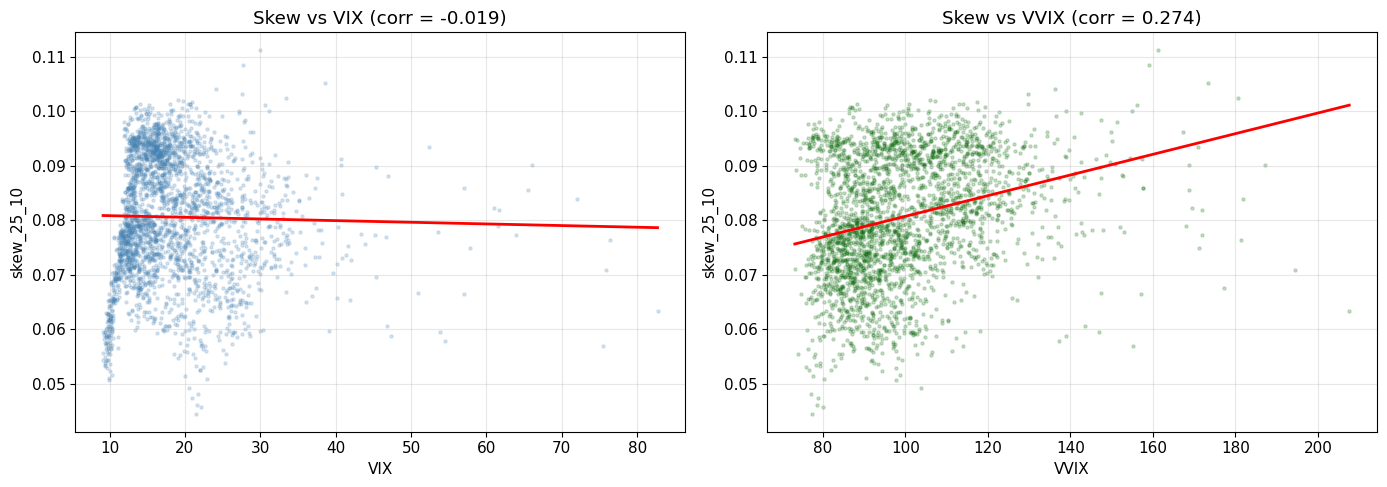

Correlation(skew, VIX):  -0.0192
Correlation(skew, VVIX): 0.2737


In [7]:
# Load VIX data
from trade_data import load_vix_data
vix_df = load_vix_data()

# Join
merged = (
    surface
    .select(['date', 'skew_25_10', 'u_price'])
    .join(vix_df.select(['date', 'VIX', 'VVIX']), on='date', how='inner')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Skew vs VIX
vix = merged['VIX'].to_numpy()
sk = merged['skew_25_10'].to_numpy()
axes[0].scatter(vix, sk, alpha=0.2, s=5, color='steelblue')
# Add regression line
m, b_line = np.polyfit(vix, sk, 1)
x_line = np.linspace(vix.min(), vix.max(), 100)
axes[0].plot(x_line, m * x_line + b_line, 'r-', linewidth=2)
corr_vix = np.corrcoef(vix, sk)[0, 1]
axes[0].set_xlabel('VIX')
axes[0].set_ylabel('skew_25_10')
axes[0].set_title(f'Skew vs VIX (corr = {corr_vix:.3f})')

# Skew vs VVIX
vvix = merged['VVIX'].drop_nulls().to_numpy()
sk_vvix = merged.filter(pl.col('VVIX').is_not_null())['skew_25_10'].to_numpy()
axes[1].scatter(vvix, sk_vvix, alpha=0.2, s=5, color='darkgreen')
m2, b2 = np.polyfit(vvix, sk_vvix, 1)
x_line2 = np.linspace(vvix.min(), vvix.max(), 100)
axes[1].plot(x_line2, m2 * x_line2 + b2, 'r-', linewidth=2)
corr_vvix = np.corrcoef(vvix, sk_vvix)[0, 1]
axes[1].set_xlabel('VVIX')
axes[1].set_ylabel('skew_25_10')
axes[1].set_title(f'Skew vs VVIX (corr = {corr_vvix:.3f})')

fig.tight_layout()
plt.show()

print(f"Correlation(skew, VIX):  {corr_vix:.4f}")
print(f"Correlation(skew, VVIX): {corr_vvix:.4f}")

## 7. Skew vs SPX Returns

Corr(20d return, 20d skew change) = 0.23 — weak positive. Skew *compresses* on selloffs (counter-intuitive at first, but these are ATM-demeaned IVs: on a crash, ATM vol spikes more than deep OTM in relative terms, so the demeaned spread narrows).

Corr(1d return, 1d skew change) = 0.13 — very weak. Daily skew changes are mostly orthogonal to direction. Good: the signal won't be dominated by delta exposure.

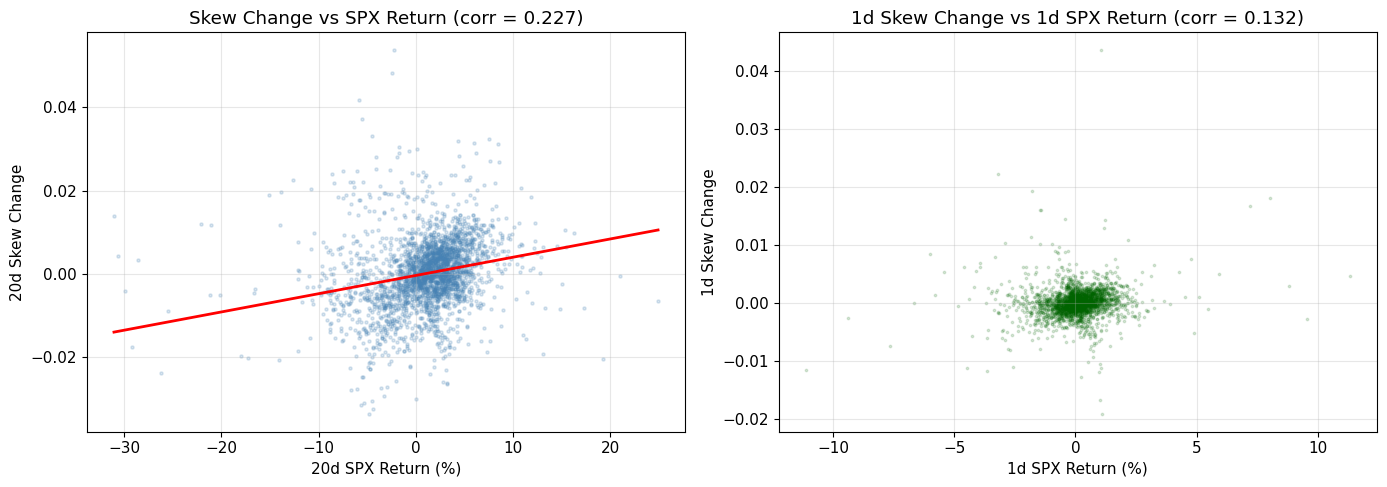

Corr(20d SPX return, 20d skew change): 0.2265
Corr(1d SPX return, 1d skew change):   0.1324


In [8]:
# 20d rolling SPX return
merged = merged.sort('date').with_columns([
    (pl.col('u_price') / pl.col('u_price').shift(20) - 1).alias('ret_20d'),
    (pl.col('skew_25_10') - pl.col('skew_25_10').shift(20)).alias('dskew_20d'),
])

valid = merged.filter(pl.col('ret_20d').is_not_null() & pl.col('dskew_20d').is_not_null())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: 20d return vs 20d skew change
ret = valid['ret_20d'].to_numpy()
dsk = valid['dskew_20d'].to_numpy()
axes[0].scatter(ret * 100, dsk, alpha=0.2, s=5, color='steelblue')
m, b_line = np.polyfit(ret, dsk, 1)
x_line = np.linspace(ret.min(), ret.max(), 100)
axes[0].plot(x_line * 100, m * x_line + b_line, 'r-', linewidth=2)
corr_ret = np.corrcoef(ret, dsk)[0, 1]
axes[0].set_xlabel('20d SPX Return (%)')
axes[0].set_ylabel('20d Skew Change')
axes[0].set_title(f'Skew Change vs SPX Return (corr = {corr_ret:.3f})')

# Scatter: contemporaneous 1d
merged_1d = merged.sort('date').with_columns([
    (pl.col('u_price') / pl.col('u_price').shift(1) - 1).alias('ret_1d'),
    (pl.col('skew_25_10') - pl.col('skew_25_10').shift(1)).alias('dskew_1d'),
])
valid_1d = merged_1d.filter(pl.col('ret_1d').is_not_null() & pl.col('dskew_1d').is_not_null())
ret1 = valid_1d['ret_1d'].to_numpy()
dsk1 = valid_1d['dskew_1d'].to_numpy()
axes[1].scatter(ret1 * 100, dsk1, alpha=0.15, s=3, color='darkgreen')
corr_1d = np.corrcoef(ret1, dsk1)[0, 1]
axes[1].set_xlabel('1d SPX Return (%)')
axes[1].set_ylabel('1d Skew Change')
axes[1].set_title(f'1d Skew Change vs 1d SPX Return (corr = {corr_1d:.3f})')

fig.tight_layout()
plt.show()

print(f"Corr(20d SPX return, 20d skew change): {corr_ret:.4f}")
print(f"Corr(1d SPX return, 1d skew change):   {corr_1d:.4f}")

## 8. Discussion

**Results summary**:

1. **Stationary**: ADF p = 0.00015. Skew is mean-reverting, not a random walk.
2. **Half-life ~26 days**: Compatible with monthly rebalancing (21 trading days). We're not too slow and not too fast.
3. **High persistence**: ACF 0.97 at lag-1, decaying exponentially. Signal changes gradually — favorable for low-turnover strategies.
4. **Independent of VIX**: Corr = -0.02. Skew trading is not a disguised vol trade.
5. **Weak directionality**: Corr(1d return, 1d skew change) = 0.13. Residual delta exposure is small but nonzero — delta hedging still warranted.
6. **Mild VVIX link**: Corr = 0.27. VVIX-based position sizing (NB 06) has some theoretical grounding here.

**Next Step**: NB 02 applies PCA to see whether the formal PC2 factor captures the same information as `skew_25_10`. If corr > 0.9, PCA is just a rotation; if lower, PCA extracts additional structure from the full put wing.